In [1]:
#from astropy.coordinates import SkyCoord
#import astropy.units as u
import sys
sys.path.append('../')
import numpy as np
from plot import *

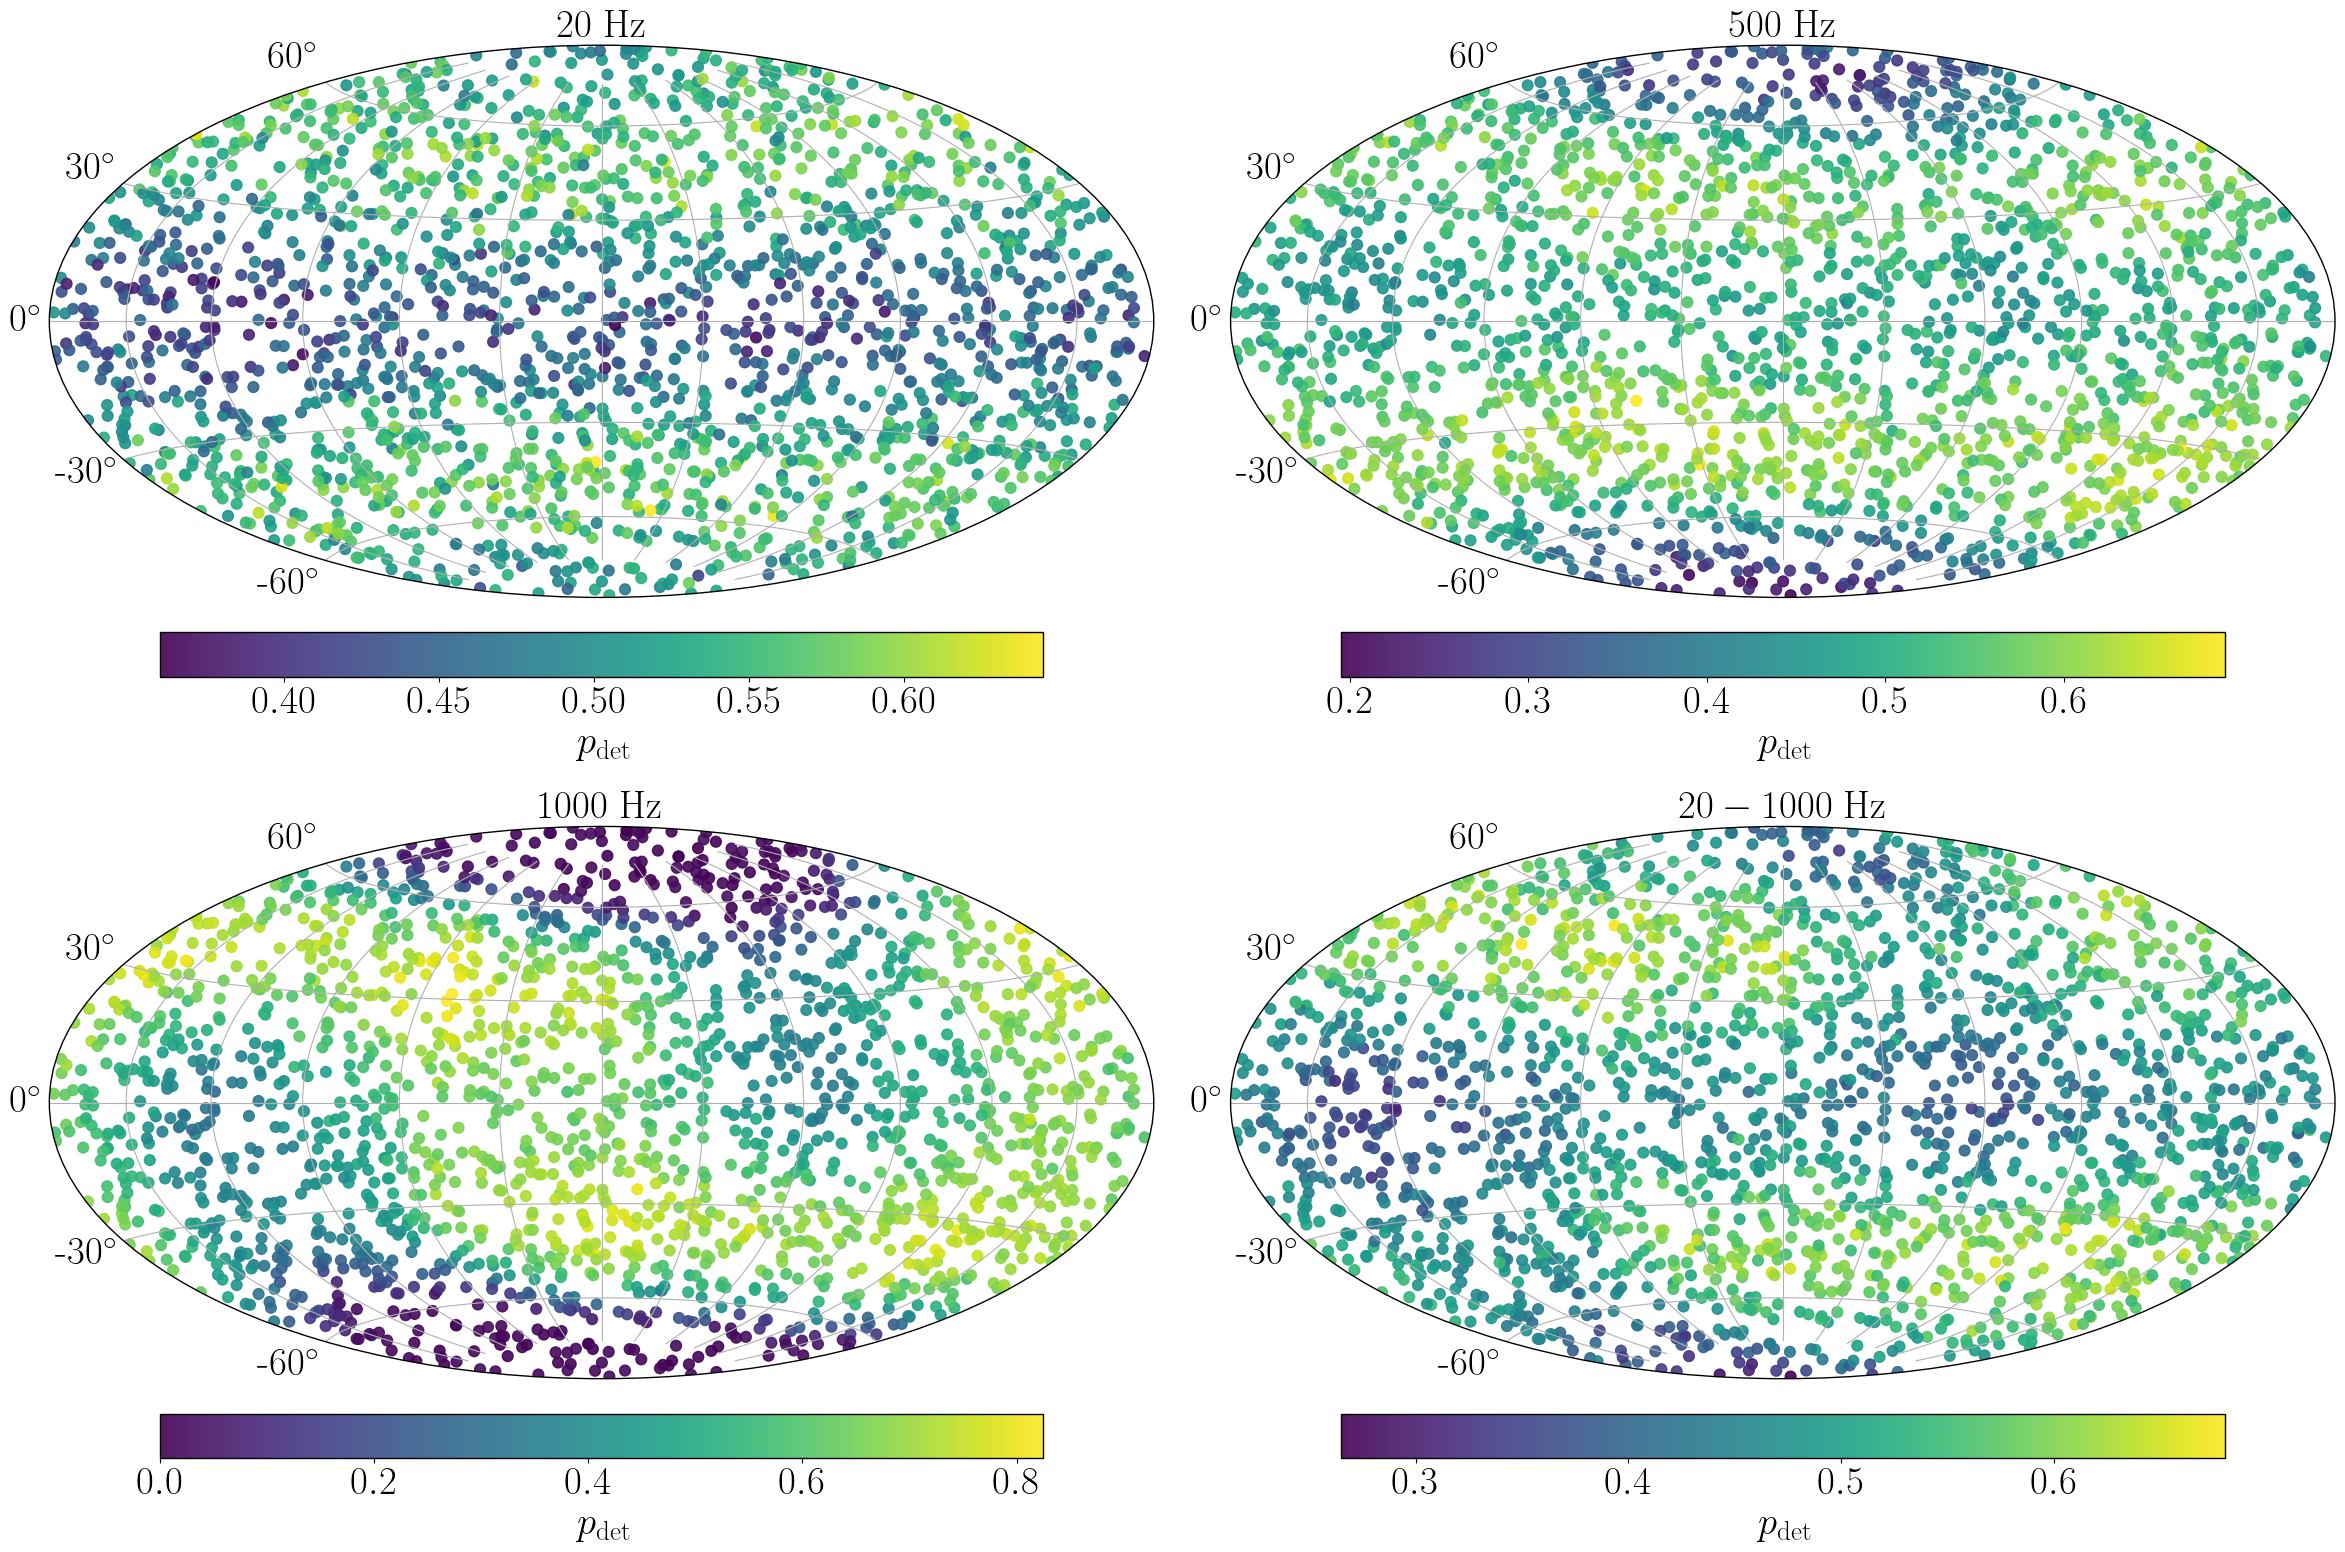

In [8]:
# Parameters
f0_values = [20, 500, 1000, 0]  # Frequencies in Hz
snr_values = [5.9, 9.5, 12, 10]
size = (512, 64)
Tsft = 14400
seeds = range(400)

alpha, delta= np.loadtxt('../../result/skygrid.txt').T

# Create figure with four subplots
fig = plt.figure(figsize=(24, 16))  # Adjusted figure size for 2x2 grid

for i, f0 in enumerate(f0_values):
    # Load data
    snr_file = f'../../result/data/snr{snr_values[i]}_skymap_{f0}Hz.npz'
    data = np.load(snr_file, allow_pickle=True)
    pdet = data['detected'].reshape(alpha.size, 200).sum(axis=1)/200

    # Process coordinates
    alpha = np.array(alpha)
    delta = np.array(delta)
    alpha[alpha > np.pi] -= 2. * np.pi  # Adjust RA to [-pi, pi]

    # Filter out invalid depths
    valid_mask = ~np.isnan(pdet)
    alpha = alpha[valid_mask]
    delta = delta[valid_mask]
    pdet = pdet[valid_mask]
    
    #print(pdet.mean())

    # Create subplot with Hammer projection
    ax = fig.add_subplot(2, 2, i+1, projection='hammer')
    
    # Scatter plot with depths as color
    scatter = ax.scatter(alpha, delta, c=pdet, s=60, alpha=0.9, 
                        cmap='viridis', 
                        vmin=np.min(pdet), 
                        vmax=np.max(pdet))

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(r'$p_\mathrm{det}$', fontsize=28)
    cbar.ax.tick_params(labelsize=28)

    # Customize the plot
    ax.grid(True)
    ax.set_xticklabels([])  # Remove RA tick labels
    dec_ticks_deg = np.array([-60, -30, 0, 30, 60])
    dec_ticks_rad = np.radians(dec_ticks_deg)
    ax.set_yticks(dec_ticks_rad)
    ax.set_yticklabels([f'{t:.0f}$^{{\\circ}}$' for t in dec_ticks_deg], fontsize=28)
    if f0 == 0:    
        #ax.set_title(f'20--1000 Hz', fontsize=28)
        ax.set_title(r'$20-1000$'+' Hz', fontsize=28)
    else:
        ax.set_title(f'{f0} Hz', fontsize=28)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show
plt.savefig('skymap.pdf')
plt.show()